## Data Exploration

### Introduction:

My **Arc Raiders Sentiment Analysis** project implements an end-to-end data engineering and NLP pipeline to track community sentiment for the video game *Arc Raiders* (developed by Embark Studios). By utilizing the YouTube Data API v3, I plan to analyze how sentiment shifts in response to game updates, roadmaps (e.g., the 2026 Roadmap), and seasonal events.

This notebook contains the exploratory data analysis (EDA) for my sentiment analysis project. The dataset consists of comment-level records enriched with associated video information, enabling both text analysis and aggregated engagement analysis. The exploration focuses on text characteristics, language distribution, sentiment indicators, and temporal engagement patterns.

### 1. Setting up modules and data

In [1]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

from collections import Counter
from datetime import datetime
from sqlalchemy import func

In [2]:
# Setting visualisation style
sns.set_style("whitegrid")
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

#### 1.1. Connecting to db

In [3]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

In [4]:
from src.database import SessionLocal, Video, Comment

In [ ]:
DB_PATH = "../arc_raiders_sentiment.db"
FIGURES_DIR = "../figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

#### 1.2. Loading the data

Dataset Review:

* **Comments Table**

  * `comment_id`: Unique identifier for each comment
  * `text`: Raw comment text
  * `comment_date`: Timestamp of comment publication
  * `parent_id`: Indicates whether the comment is a reply
  * `author_hash`: Anonymized identifier for users
  * `last_updated_at`: Last modification timestamp

* **Videos Table**

  * `video_id`: Unique identifier for each video
  * `video_title`
  * `video_date`
  * `channel_id`
  * `keyword_matched`: Whether the video was selected via keyword filtering
  * `video_description`
  * `comments_disabled`

The join between `comments` and `videos` allows for multi-dimensional analysis across:

* Text characteristics
* Temporal patterns
* Engagement behavior
* Video-level performance

In [6]:
session = SessionLocal()
conn = sqlite3.connect(DB_PATH)

comments_query = """
SELECT 
    c.comment_id,
    c.text,
    c.published_at AS comment_date,
    c.author_hash,
    c.parent_id,
    c.last_updated_at,
    v.video_id,
    c.like_count as likes,
    v.title AS video_title,
    v.published_at AS video_date,
    v.channel_id,
    v.keyword_matched,
    v.description AS video_description
FROM comments c
JOIN videos v ON c.video_id = v.video_id
"""

df = pd.read_sql_query(comments_query, conn)

video_query = """
SELECT 
    v.video_id,
    v.title,
    v.published_at,
    v.channel_id,
    v.keyword_matched,
    v.comments_disabled,
    COUNT(c.comment_id) AS comment_count
FROM videos v
LEFT JOIN comments c ON v.video_id = c.video_id
GROUP BY v.video_id
"""

video_df = pd.read_sql_query(video_query, conn)

conn.close()
session.close()

df["comment_date"] = pd.to_datetime(df["comment_date"])
df["video_date"] = pd.to_datetime(df["video_date"])
video_df["published_at"] = pd.to_datetime(video_df["published_at"])

print(f"Loaded {len(df):,} comments from {len(video_df):,} videos")

Loaded 258,443 comments from 2,075 videos


In [7]:
df.head(5)

,comment_id,text,comment_date,author_hash,parent_id,last_updated_at,video_id,likes,video_title,video_date,channel_id,keyword_matched,video_description
0,UgxEgHTlwp52_t7tvld4AaABAg,this video is literally a lie - Arc Raiders do...,2026-03-12 09:00:00,00c95ebeeeb9b2094e02791c81e2ac9cd9e3a68724e2c5...,NaN,2026-03-12 09:00:00.000000,xuftkDxjGT4,1,Arc Raiders Reveal Trailer | Game Awards 2021,2021-12-10 03:58:14,UCbu2SsF-Or3Rsn3NxqODImw,Arc Raiders,Check out the world premiere reveal trailer fo...
1,UgxfQBIpu5Q9a2pqKD54AaABAg,Caraca não sabia que era tão antigo,2026-03-12 03:34:19,bef66a381d8737e126860408d372d8d4e8e463419de30a...,NaN,2026-03-12 03:34:19.000000,xuftkDxjGT4,0,Arc Raiders Reveal Trailer | Game Awards 2021,2021-12-10 03:58:14,UCbu2SsF-Or3Rsn3NxqODImw,Arc Raiders,Check out the world premiere reveal trailer fo...
2,Ugx2KM9kJqjh_mesOIZ4AaABAg,😮This trailer is the greatest prequel lore in ...,2026-03-10 23:32:15,31c593066ff6110d558cc310a246c895d7bcf840d91e93...,NaN,2026-03-10 23:32:15.000000,xuftkDxjGT4,0,Arc Raiders Reveal Trailer | Game Awards 2021,2021-12-10 03:58:14,UCbu2SsF-Or3Rsn3NxqODImw,Arc Raiders,Check out the world premiere reveal trailer fo...
3,Ugyt0PrH_pOeXqKrYRN4AaABAg,holy false advertising,2026-03-10 17:56:56,8890a908eaecc345c51e5e6716db3766e3b4044fbd0434...,NaN,2026-03-10 17:56:56.000000,xuftkDxjGT4,2,Arc Raiders Reveal Trailer | Game Awards 2021,2021-12-10 03:58:14,UCbu2SsF-Or3Rsn3NxqODImw,Arc Raiders,Check out the world premiere reveal trailer fo...
4,UgxIu-puc-eEI2TVJ4h4AaABAg,Best game,2026-03-10 09:58:20,4ad74d9af134db04afdc8d76a0b60d2193b82d12ac29a3...,NaN,2026-03-10 09:58:20.000000,xuftkDxjGT4,0,Arc Raiders Reveal Trailer | Game Awards 2021,2021-12-10 03:58:14,UCbu2SsF-Or3Rsn3NxqODImw,Arc Raiders,Check out the world premiere reveal trailer fo...


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 258443 entries, 0 to 258442
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   comment_id         258443 non-null  str           
 1   text               258443 non-null  str           
 2   comment_date       258443 non-null  datetime64[us]
 3   author_hash        258443 non-null  str           
 4   parent_id          60200 non-null   str           
 5   last_updated_at    258443 non-null  str           
 6   video_id           258443 non-null  str           
 7   likes              258443 non-null  int64         
 8   video_title        258443 non-null  str           
 9   video_date         258443 non-null  datetime64[us]
 10  channel_id         258443 non-null  str           
 11  keyword_matched    258443 non-null  str           
 12  video_description  258443 non-null  str           
dtypes: datetime64[us](2), int64(1), str(10)
memory usage: 1

### 2. Summary of the data

In [9]:
print(f"Total Videos: {len(video_df):,}")
print(f"Total Comments: {len(df):,}")
print(f"Unique Channels: {video_df['channel_id'].nunique():,}")
print(f"Unique Commenters: {df['author_hash'].nunique():,}")
print(f"Date Range of Videos: {video_df['published_at'].min().date()} to {video_df['published_at'].max().date()}")
print(f"Date Range of Comments: {df['comment_date'].min().date()} to {df['comment_date'].max().date()}")

Total Videos: 2,075
Total Comments: 258,443
Unique Channels: 941
Unique Commenters: 147,062
Date Range of Videos: 2021-12-10 to 2026-03-17
Date Range of Comments: 2021-12-10 to 2026-03-14


In [10]:
disabled = video_df['comments_disabled'].sum()
print(f"\n{'DATA QUALITY':^60}")
print("-"*60)
print(f"{'Videos with comments disabled:':<40} {disabled}")
print(f"{'Videos with 0 comments:':<40} {(video_df['comment_count'] == 0).sum()}")

comments_per_video = df.groupby("video_id").size()
print(f"{'Mean comments per video:':<40} {comments_per_video.mean():.2f}")
print(f"{'Median comments per video:':<40} {comments_per_video.median():.2f}")


                        DATA QUALITY                        
------------------------------------------------------------
Videos with comments disabled:           11
Videos with 0 comments:                  496
Mean comments per video:                 163.68
Median comments per video:               37.00


### 3. Text-Based Exploration

Understanding comment length is important for both modeling and preprocessing decisions.

Key motivations:

* Detect unusually long or short comments
* Identify spam-like or low-effort comments
* Prepare for transformer-based models with token limits

#### 3.1 Text Length Analysis:

In [11]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df["avg_word_length"] = df["char_count"] / df["word_count"].replace(0, 1)

df["has_url"] = df["text"].str.contains(r"http[s]?://", regex=True, na=False)
df["has_mention"] = df["text"].str.contains(r"@\w+", regex=True, na=False)
df["has_hashtag"] = df["text"].str.contains(r"#\w+", regex=True, na=False)

df["exclamation_count"] = df["text"].str.count("!")
df["question_count"] = df["text"].str.count(r"\?")
df["emoji_count"] = df["text"].apply(lambda x: len([c for c in str(x) if '\U0001F300' <= c <= '\U0001F9FF']))
df["newline_count"] = df["text"].str.count("\n")

df["uppercase_ratio"] = df["text"].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) else 0
)

In [12]:
print(df[["char_count", "word_count"]].describe())

long_comments = (df["word_count"] > 100).mean() * 100
print(f"\nComments >100 words: {long_comments:.2f}%")

          char_count     word_count
count  258443.000000  258443.000000
mean      101.440507      18.995167
std       151.286644      27.784100
min         0.000000       0.000000
25%        30.000000       6.000000
50%        60.000000      11.000000
75%       117.000000      22.000000
max      8287.000000    1586.000000

Comments >100 words: 1.68%


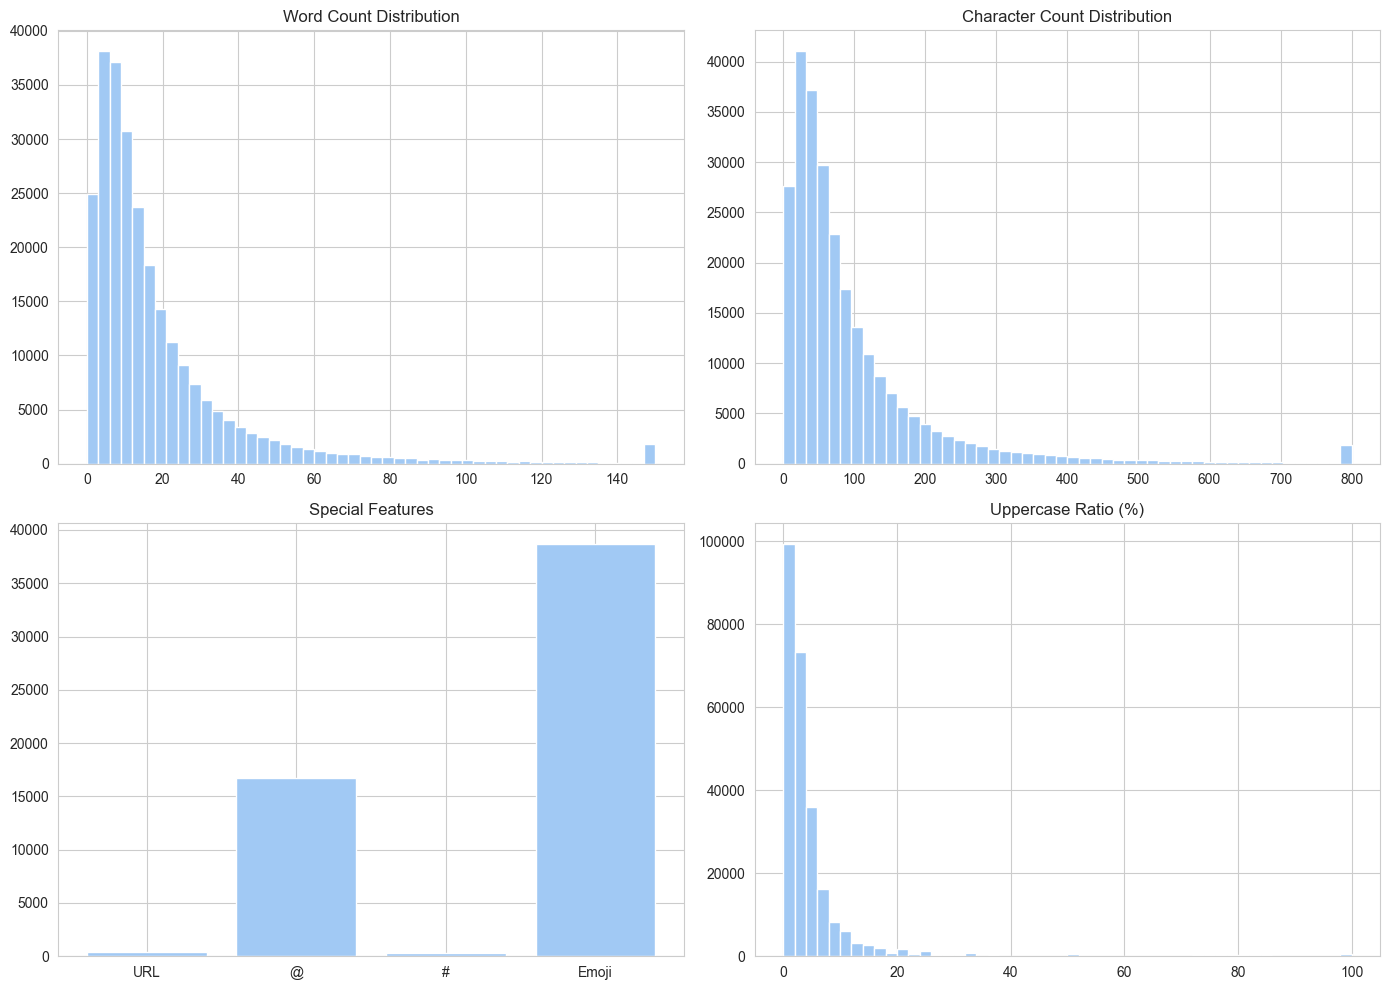

In [13]:
def plot_text_characteristic(df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].hist(df["word_count"].clip(upper=150), bins=50)
    axes[0, 0].set_title("Word Count Distribution")

    axes[0, 1].hist(df["char_count"].clip(upper=800), bins=50)
    axes[0, 1].set_title("Character Count Distribution")

    features = [
        df["has_url"].sum(),
        df["has_mention"].sum(),
        df["has_hashtag"].sum(),
        (df["emoji_count"] > 0).sum(),
    ]

    axes[1, 0].bar(["URL", "@", "#", "Emoji"], features)
    axes[1, 0].set_title("Special Features")

    axes[1, 1].hist(df["uppercase_ratio"] * 100, bins=50)
    axes[1, 1].set_title("Uppercase Ratio (%)")

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "01_text_characteristic.png"), dpi=300)
    plt.show()

plot_text_characteristic(df)

##### 3.1.1 Character limt: RoBERTa-specific

Planning to use a RoBERTa based NLP model to classify the sentiment analysis brings on a unique issue: the model has a token limit of 512 tokens per input. So the length of comments are something to be considered in the next step of data wrangling - on how to trim them.

Implications:

* Comments exceeding the token limit must be truncated or split
* Extremely long comments may bias the model

This step ensures the NLP pipeline is technically feasible and computationally efficient.

In [14]:
very_long = (df['word_count'] > 100).sum()
medium = ((df['word_count'] > 50) & (df['word_count'] <= 100)).sum()
short = (df['word_count'] <= 50).sum()
print(f"{'Comments <= 50 words:':<40} {short:>10,} ({short/len(df)*100:>5.1f}%)")
print(f"{'Comments 51-100 words:':<40} {medium:>9,} ({medium/len(df)*100:>5.1f}%)")
print(f"{'Comments > 100 words (may need truncation):'} {very_long} ({very_long/len(df)*100:>5.1f}%)")

Comments <= 50 words:                       240,689 ( 93.1%)
Comments 51-100 words:                      13,419 (  5.2%)
Comments > 100 words (may need truncation): 4335 (  1.7%)


#### 3.2 Word Frequency Analysis

Word frequency analysis provides insight into:

* Dominant discussion themes
* Recurring terminology
* Community vocabulary patterns

This stage forms the foundation for gaming-specific keyword detection and **feature engineering** for classification in the coming steps.

In [15]:
stopwords = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
            'of', 'with', 'is', 'are', 'was', 'were', 'been', 'be', 'have', 'has',
            'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'can',
            'this', 'that', 'these', 'those', 'it', 'its', 'i', 'you', 'he', 'she',
            'we', 'they', 'them', 'my', 'your', 'his', 'her', 'our', 'their', 'not',
            'just', 'get', 'got', 'like', 'so', 'really', 'even', 'one', 'know',
            'im', 'dont', 'thats', 'youre', 'cant', 'wont', 'isnt', 'arent'}

In [16]:
all_text = " ".join(df["text"].str.lower())
words = re.findall(r"\b[a-z]{3,}\b", all_text)
filtered_words = [w for w in words if w not in stopwords]

word_freq = Counter(filtered_words)

word_freq.most_common(20)

[('game', 36676),
 ('arc', 19266),
 ('all', 16955),
 ('pvp', 14754),
 ('what', 14612),
 ('people', 13933),
 ('more', 13405),
 ('out', 12727),
 ('when', 12707),
 ('there', 11855),
 ('good', 11832),
 ('don', 11502),
 ('from', 11338),
 ('play', 11194),
 ('how', 10437),
 ('about', 10391),
 ('only', 10310),
 ('pve', 10219),
 ('raiders', 10004),
 ('time', 9969)]

#### 3.3. Languages

Since YouTube has a global audience, language detection was performed to:

* Identify multilingual content
* Quantify the proportion of English vs non-English comments
* Determine whether filtering or multilingual modeling is required

As my sentiment modeling is English-only, non-English comments may need:

* Translation
* Removal
* Separate modeling pipelines

In [17]:
from langdetect import detect, LangDetectException

In [18]:
def safe_detect(text):
        try:
            if pd.isna(text) or len(str(text).strip()) < 3:
                return 'unknown'
            return detect(str(text))
        except LangDetectException:
            return 'unknown'
        except Exception:
            return 'unknown'

In [19]:
df['language'] = df['text'].apply(safe_detect)

In [20]:
lang_counts = Counter(df['language'])

In [21]:
total = len(df)
english_count = lang_counts.get('en', 0)

print(f"{'Total comments analyzed:':<40} {total:>10,}")
print(f"{'English comments:':<40} {english_count:>10,} ({english_count/total*100:>5.1f}%)")
print(f"{'Non-English comments:':<40} {total - english_count:>10,} ({(total-english_count)/total*100:>5.1f}%)")
print(f"{'Unique languages detected:':<40} {len(lang_counts):>10,}")

Total comments analyzed:                    258,443
English comments:                           195,202 ( 75.5%)
Non-English comments:                        63,241 ( 24.5%)
Unique languages detected:                       47


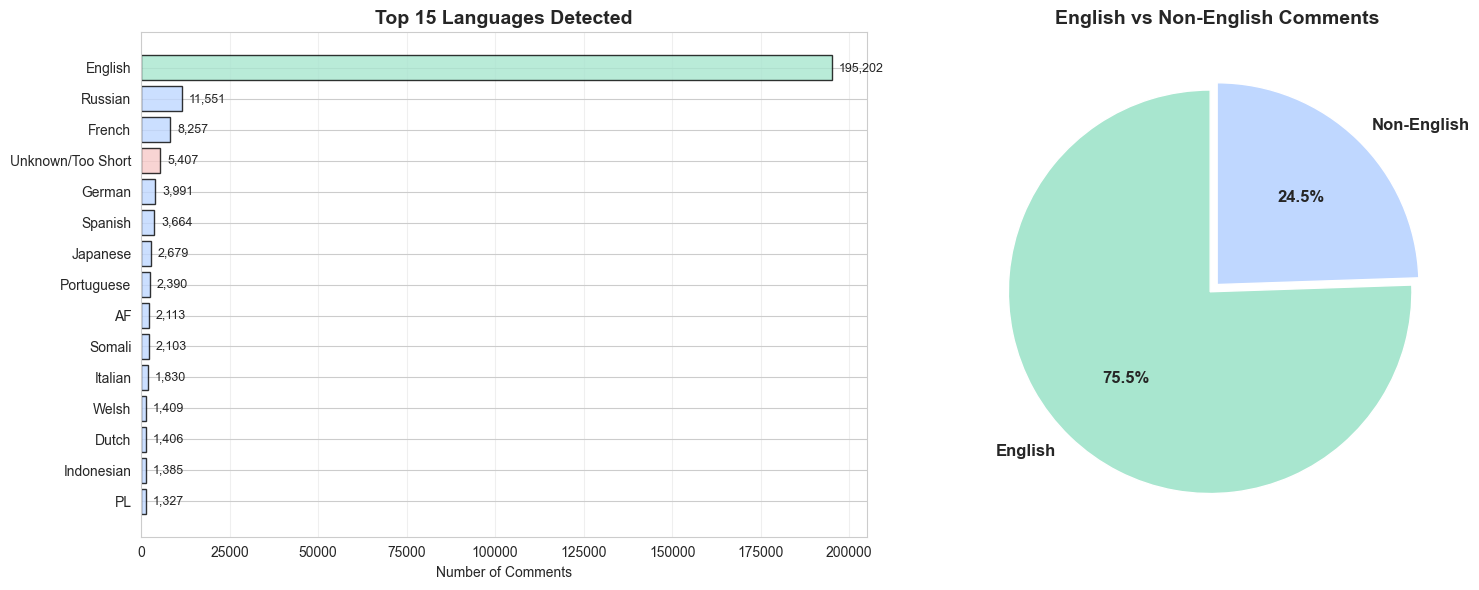

In [22]:
lang_names_map = {
        'en': 'English', 'es': 'Spanish', 'fr': 'French', 'de': 'German',
        'it': 'Italian', 'pt': 'Portuguese', 'nl': 'Dutch', 'ru': 'Russian',
        'ja': 'Japanese', 'ko': 'Korean', 'zh-cn': 'Chinese (Simplified)',
        'zh-tw': 'Chinese (Traditional)', 'ar': 'Arabic', 'ta': 'Tamil',
        'so': 'Somali', 'no': 'Norwegian', 'da': 'Danish', 'vi': 'Vietnamese',
        'cy': 'Welsh', 'tl': 'Tagalog', 'id': 'Indonesian', 'et': 'Estonian',
        'ca': 'Catalan', 'ro': 'Romanian', 'bg': 'Bulgarian', 'uk': 'Ukrainian',
        'unknown': 'Unknown/Too Short'
}

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax_bar, ax_pie = axes

# 1. Top 15 languages bar chart
top_15 = dict(lang_counts.most_common(15))
languages = [lang_names_map.get(k, k.upper()) for k in top_15.keys()]
counts = list(top_15.values())
colors = [
    '#A8E6CF' if 'English' in lang else '#F7CAC9' if 'Unknown' in lang else '#BFD7FF'
    for lang in languages
]

ax_bar.barh(range(len(languages)), counts, color=colors, edgecolor='black', alpha=0.8)
ax_bar.set_yticks(range(len(languages)))
ax_bar.set_yticklabels(languages)
ax_bar.set_xlabel('Number of Comments')
ax_bar.set_title('Top 15 Languages Detected', fontsize=14, fontweight='bold')
ax_bar.invert_yaxis()
ax_bar.grid(True, alpha=0.3, axis='x')

# Add count labels
for i, (count, lang) in enumerate(zip(counts, languages)):
    ax_bar.text(count + max(counts) * 0.01, i, f'{count:,}', va='center', fontsize=9)

# 2. English vs Non-English pie chart
english_vs_other = {'English': english_count, 'Non-English': total - english_count}
colors_pie = ['#A8E6CF', '#BFD7FF']
explode = (0.05, 0)

ax_pie.pie(
    english_vs_other.values(),
    labels=english_vs_other.keys(),
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_pie,
    explode=explode,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
ax_pie.set_title('English vs Non-English Comments', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_language_distribution.png"), dpi=300)
plt.show()

#### 3.4. Game-specific terminology detection

Custom keyword detection was used to identify:

* Core game mechanics references
* Character names
* Community slang
* Feature-specific discussions

In [23]:
game_terms = ['game', 'gameplay', 'play', 'players', 'player', 'playing',
                'graphics', 'trailer', 'raid', 'raiders', 'arc', 'beta', 'alpha',
                'bugs', 'bug', 'glitch', 'update', 'patch', 'season', 'pvp', 'pve']

print(f"\n{'GAME-SPECIFIC TERMINOLOGY':^80}")
print("-"*80)
for term in game_terms:
    count = word_freq.get(term, 0)
    if count > 0:
        print(f"{term:.<25} {count:>8,} times")


                           GAME-SPECIFIC TERMINOLOGY                            
--------------------------------------------------------------------------------
game.....................   36,676 times
gameplay.................    1,717 times
play.....................   11,194 times
players..................    7,535 times
player...................    4,346 times
playing..................    5,511 times
graphics.................      406 times
trailer..................      904 times
raid.....................    2,877 times
raiders..................   10,004 times
arc......................   19,266 times
beta.....................      344 times
alpha....................      259 times
bugs.....................      365 times
bug......................      670 times
glitch...................      548 times
update...................    1,372 times
patch....................      535 times
season...................      636 times
pvp......................   14,754 times
pve..............

#### 3.5. Sentiment Indicating Words

Before full sentiment modeling, lexical indicators were explored.

This allows:

* Quick heuristic sentiment estimation
* Early detection of polarity trends

In [24]:
positive_indicators = ['love', 'great', 'amazing', 'awesome', 'good', 'best',
                        'perfect', 'excellent', 'fun', 'enjoy', 'beautiful']
negative_indicators = ['hate', 'bad', 'worst', 'terrible', 'awful', 'boring',
                        'disappointed', 'disappointing', 'broken', 'trash', 'garbage']

print(f"\n{'SENTIMENT INDICATOR WORDS':^40}")
print("-"*40)
print("Positive indicators:")
for word in positive_indicators:
    count = word_freq.get(word, 0)
    if count > 0:
        print(f"  {word:.<20} {count:>6,} times")

print("\nNegative indicators:")
for word in negative_indicators:
    count = word_freq.get(word, 0)
    if count > 0:
        print(f"  {word:.<20} {count:>6,} times")


       SENTIMENT INDICATOR WORDS        
----------------------------------------
Positive indicators:
  love................  8,039 times
  great...............  5,045 times
  amazing.............  1,889 times
  awesome.............  1,734 times
  good................ 11,832 times
  best................  4,305 times
  perfect.............    730 times
  excellent...........    338 times
  fun.................  4,840 times
  enjoy...............  1,472 times
  beautiful...........    417 times

Negative indicators:
  hate................  2,020 times
  bad.................  3,342 times
  worst...............    823 times
  terrible............    670 times
  awful...............    214 times
  boring..............  1,537 times
  disappointed........    270 times
  disappointing.......    129 times
  broken..............    704 times
  trash...............  1,214 times
  garbage.............    521 times


### 4. Time-Based Analysis

Time-based aggregation enables detection of:

* Comment volume spikes
* Event-driven engagement
* Viral moments

From the analysis:

* ~14% of total comment volume occurred during statistically significant spike days.
* These spikes were largely driven by a small subset of high-performing videos.

Further deep dive and inspection is necessary to interpret spike causes. Some possible reasons are:

* Major announcements
* Controversy
* Updates or patches
* Influencer amplification

In [25]:
# Daily statistics
daily_comments = df.groupby(df['comment_date'].dt.date).size()

# Day of week patterns
df['day_of_week'] = df['comment_date'].dt.day_name()
df['day_num'] = df['comment_date'].dt.dayofweek
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df['day_of_week'].value_counts().reindex(day_order)

In [26]:
# Daily comment counts
daily_counts = df.groupby(df['comment_date'].dt.date).size()
daily_counts = daily_counts.rename('comment_count').reset_index()
daily_counts['date'] = pd.to_datetime(daily_counts['comment_date'])

# --- Spike detection using rolling z-score ---
launch_date = pd.Timestamp('2025-10-30')

daily_comments.index = pd.to_datetime(daily_comments.index)

rolling_mean = daily_comments.rolling(30, min_periods=7).mean()
rolling_std = daily_comments.rolling(30, min_periods=7).std()

z_scores = (daily_comments - rolling_mean) / rolling_std

before_launch = daily_comments.index < launch_date
after_launch = daily_comments.index >= launch_date

is_spike = (
    (before_launch & (z_scores > 3)) |
    (after_launch & (z_scores > 2.5)))

spike_dates = daily_comments[is_spike].index
spike_values = daily_comments[is_spike].values

print("Detected Spike Dates:")
print(spike_dates)

Detected Spike Dates:
DatetimeIndex(['2022-01-21', '2022-01-22', '2022-02-28', '2022-05-04',
               '2022-05-05', '2022-07-27', '2022-07-28', '2022-07-29',
               '2022-07-30', '2022-08-09', '2022-12-03', '2023-01-05',
               '2023-01-06', '2023-01-08', '2023-01-09', '2023-01-10',
               '2023-04-04', '2023-04-25', '2023-05-16', '2023-05-17',
               '2023-05-21', '2023-10-27', '2023-11-13', '2024-02-17',
               '2024-02-27', '2024-03-01', '2024-04-27', '2024-05-27',
               '2024-05-28', '2024-06-05', '2024-07-10', '2024-08-20',
               '2024-10-09', '2024-10-22', '2024-10-23', '2024-11-12',
               '2025-04-13', '2025-04-15', '2025-04-16', '2025-05-05',
               '2025-09-22', '2025-09-23', '2025-09-24', '2025-10-18',
               '2025-10-19', '2025-10-20', '2025-11-29', '2025-11-30',
               '2025-12-01', '2025-12-05', '2026-01-11', '2026-01-16',
               '2026-01-17', '2026-02-15', '2026-02-23'

In [27]:
total_comments = len(df)
spike_comments_total = df[df['comment_date'].dt.normalize().isin(spike_dates)].shape[0]
event_driven_pct = (spike_comments_total / total_comments) * 100

print(f"Total Comments: {total_comments:,}")
print(f"Spike-Day Comments: {spike_comments_total:,}")
print(f"Event-Driven Share: {event_driven_pct:.2f}%")

Total Comments: 258,443
Spike-Day Comments: 38,641
Event-Driven Share: 14.95%


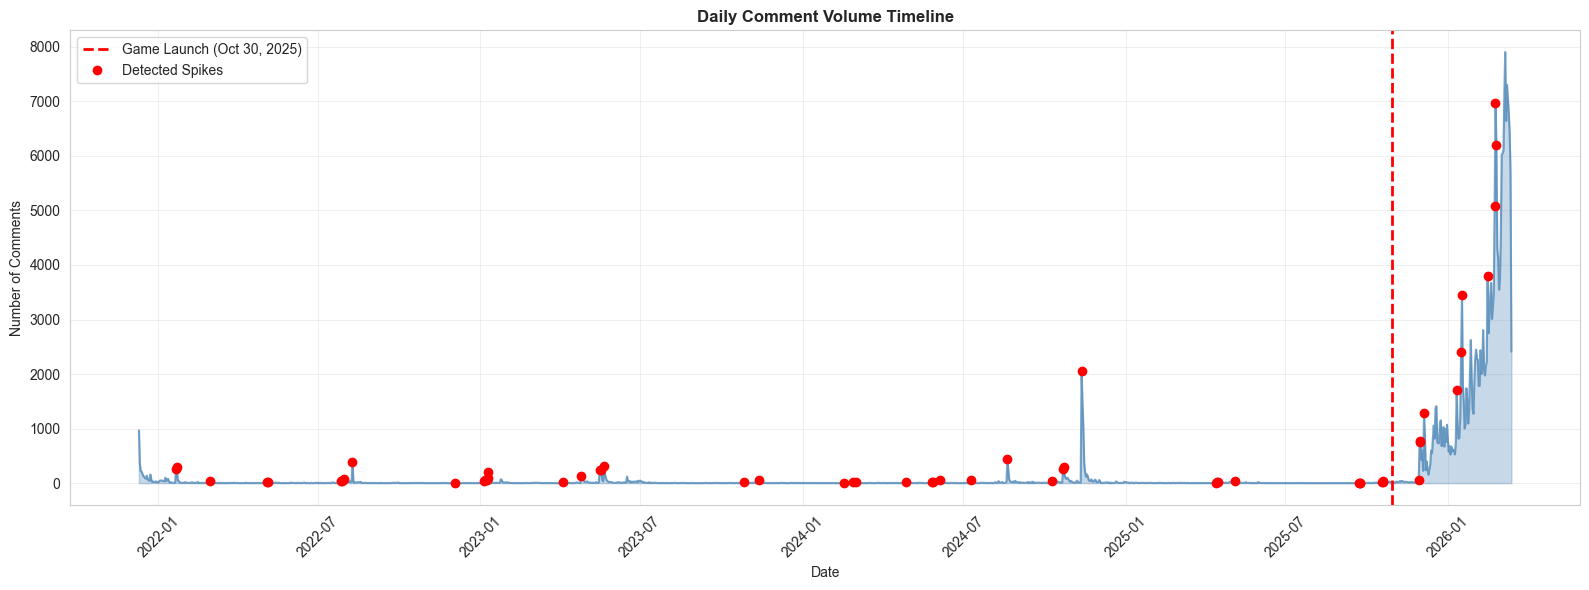

In [28]:
fig, axes = plt.subplots(figsize=(16, 6))

# 1. Daily timeline
axes.plot(daily_comments.index, daily_comments.values,
             linewidth=1.5, color='steelblue', alpha=0.7)
axes.fill_between(daily_comments.index, daily_comments.values,
                     alpha=0.3, color='steelblue')

# Highlight important dates
axes.axvline(launch_date, color='red', linestyle='--',
                linewidth=2, label='Game Launch (Oct 30, 2025)')

# Highlight spike days
axes.plot(
    spike_dates,
    spike_values,
    'o',
    color='red',
    markersize=6,
    label='Detected Spikes')
axes.legend()
axes.set_title('Daily Comment Volume Timeline', fontsize=12, fontweight='bold')
axes.set_xlabel('Date')
axes.set_ylabel('Number of Comments')
axes.grid(True, alpha=0.3)
axes.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_temporal_patterns.png'), dpi=300, bbox_inches='tight')
plt.show()

In [29]:
print(len(spike_dates))
print(spike_dates[:10])

57
DatetimeIndex(['2022-01-21', '2022-01-22', '2022-02-28', '2022-05-04',
               '2022-05-05', '2022-07-27', '2022-07-28', '2022-07-29',
               '2022-07-30', '2022-08-09'],
              dtype='datetime64[s]', name='comment_date', freq=None)


In [30]:
# Filter comments on spike days
df['comment_date'] = pd.to_datetime(df['comment_date'])

spike_comments = df[
    df['comment_date'].dt.normalize().isin(spike_dates)
]

# Count comments per video on spike days
spike_video_counts = (
    spike_comments
    .groupby(['video_id', 'video_title'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name='comment_count')
)

top_spike_videos = spike_video_counts.head(10)
top_spike_videos

,video_id,video_title,comment_count
0,iUaI3j-v7Qg,"Шутер, в котором нельзя стрелять? | Arc Raiders",1708
1,fSkcVzW3Mxo,ARC Raiders MEGA UPDATE! Huge Weapon Nerfs!,1643
2,xPaKRV76Tlc,Shrouded Sky Update | ARC Raiders,1445
3,x2-SUp4TtjU,Arc Raiders - LE JEU QUI REND PARANO,1029
4,yFO6gyuYnrI,I Wish I Learned This 300 Hours Ago... In Arc ...,852
5,OVx5ZoesA1Q,Shroud&#39;s Take on Peanut Threatening He Wil...,852
6,O749EdpXeu0,How Arc Raiders Matchmaking Punishes More Aggr...,659
7,FgVjdLr5gIY,Arc Raiders Gameplay and Impressions...,591
8,q9aN7y7VBpY,ARC Raiders – I Tested the Aggression Based Ma...,590
9,dAa-lkp5vSs,【珍展開】野良で出会った侍ニキw【アークレイダーズ/ARC Raiders】 #arcrai...,581


- We can conclude that **~14%** of total comment volume occurred during statistically significant spike days, primarily driven by **9 high-performing videos**.

- Further deep dive is necessary to find the exact reasons for these spikes, and as well as whether they were about something positive about the game, negative, or otherwise.

In [31]:
# Adding the spike information back to the main dataframe
spike_info = pd.DataFrame({
    'date': daily_comments.index,
    'is_spike': is_spike.values,
    'z_score': z_scores.values})

df['date'] = df['comment_date'].dt.normalize()
df = df.merge(
    spike_info,
    left_on='date',
    right_on='date',
    how='left')

df['is_spike'] = df['is_spike'].fillna(False)

### 5. Engagement Metrics

Video-level aggregation enables analysis of:

* Comment count per video
* Distribution skewness
* Long-tail engagement patterns

Some of my observations are:

* A small percentage of videos generate the majority of comments.
* Comment-disabled videos impact engagement distribution.
* Keyword-matched videos may correlate with higher engagement.

In [32]:
# Comments per video
comments_per_video = df.groupby('video_id').size().sort_values(ascending=False)

print(f"{'ENGAGEMENT DISTRIBUTION':^60}")
print("-"*60)
print(f"{'Mean comments per video:':<40} {comments_per_video.mean():>10.1f}")
print(f"{'Median comments per video:':<40} {comments_per_video.median():>10.1f}")
print(f"{'Std deviation:':<40} {comments_per_video.std():>10.1f}")
print(f"{'Most commented video:':<40} {comments_per_video.max():>10,} comments")
print(f"{'Least commented video:':<40} {comments_per_video.min():>10,} comments")

                  ENGAGEMENT DISTRIBUTION                   
------------------------------------------------------------
Mean comments per video:                      163.7
Median comments per video:                     37.0
Std deviation:                                329.0
Most commented video:                         4,043 comments
Least commented video:                            1 comments


In [33]:
# Engagement tiers
very_high = (comments_per_video > comments_per_video.quantile(0.9)).sum()
high = ((comments_per_video > comments_per_video.quantile(0.75)) & 
        (comments_per_video <= comments_per_video.quantile(0.9))).sum()
medium = ((comments_per_video > comments_per_video.quantile(0.5)) & 
            (comments_per_video <= comments_per_video.quantile(0.75))).sum()
low = (comments_per_video <= comments_per_video.quantile(0.5)).sum()

print(f"\n{'ENGAGEMENT TIERS':^60}")
print("-"*60)
print(f"{'Very High (top 10%):':<40} {very_high:>10,} videos")
print(f"{'High (75-90th percentile):':<40} {high:>10,} videos")
print(f"{'Medium (50-75th percentile):':<40} {medium:>10,} videos")
print(f"{'Low (bottom 50%):':<40} {low:>10,} videos")


                      ENGAGEMENT TIERS                      
------------------------------------------------------------
Very High (top 10%):                            158 videos
High (75-90th percentile):                      236 videos
Medium (50-75th percentile):                    392 videos
Low (bottom 50%):                               793 videos


In [34]:
# Top videos
print(f"\n{'TOP 15 MOST COMMENTED VIDEOS':^80}")
print("-"*80)
top_videos = df.groupby(['video_id', 'video_title']).size().sort_values(ascending=False).head(15)
for i, ((vid_id, title), count) in enumerate(top_videos.items(), 1):
    print(f"{i:>2}. {count:>5,} comments - {title[:65]}")


                          TOP 15 MOST COMMENTED VIDEOS                          
--------------------------------------------------------------------------------
 1. 4,043 comments - Creating Custom POKEMON For YOU! (Arc Raiders Edition)
 2. 3,527 comments - Arc Raiders Reveal Trailer | Game Awards 2021
 3. 3,436 comments - Шутер, в котором нельзя стрелять? | Arc Raiders
 4. 3,230 comments - Shroud is Done With Arc Raiders
 5. 2,527 comments - ARC Raiders – I Tested the Aggression Based Matchmaking (Here’s H
 6. 2,260 comments - The ARC Raiders situation presented by AM
 7. 2,240 comments - The Greatest Play In ARC Raiders History
 8. 2,239 comments - Arc Raiders - LE JEU QUI REND PARANO
 9. 1,925 comments - 【珍展開】野良で出会った侍ニキw【アークレイダーズ/ARC Raiders】 #arcraiders #アークレイダーズ
10. 1,714 comments - Will 500 Synthesized Fuel One Shot The Queen...? | ARC Raiders
11. 1,704 comments - Will this PvE mode destroy ARC Raiders PvP?
12. 1,701 comments - Я провел 400 часов в ARC Raiders и вот что хочу ск

In [35]:
# Channel analysis
channel_stats = df.groupby('channel_id').agg({
    'video_id': 'nunique',
    'comment_id': 'count'
}).rename(columns={'video_id': 'video_count', 'comment_id': 'comment_count'})
channel_stats = channel_stats.sort_values('comment_count', ascending=False)

print(f"\n{'TOP 10 CHANNELS BY COMMENT VOLUME':^80}")
print("-"*80)
for i, (channel_id, row) in enumerate(channel_stats.head(10).iterrows(), 1):
    print(f"{i:>2}. Channel {channel_id[:20]:>20} - {row['video_count']:>3} videos, "
            f"{row['comment_count']:>6,} comments")


                       TOP 10 CHANNELS BY COMMENT VOLUME                        
--------------------------------------------------------------------------------
 1. Channel UCMNEVbszv8ZyvSXoTn3 -  48 videos, 17,039 comments
 2. Channel UCz2_M6-NBgdiLvDOmlH -  26 videos, 10,898 comments
 3. Channel UC8D47Pv6mdRHgzIzxsy -  12 videos,  9,407 comments
 4. Channel UC1GHEmBm9olV2m_85H- -  10 videos,  9,053 comments
 5. Channel UCghVgPYA_pB7MdbDVai -  15 videos,  8,266 comments
 6. Channel UCwGvjW2qPoyp_vP8Ui3 -  10 videos,  5,851 comments
 7. Channel UCnOOuJbLVsiwVEFaKsv -  20 videos,  5,582 comments
 8. Channel UCRj5GjfzS2erdM-2-qa -   9 videos,  4,832 comments
 9. Channel UCHvATl70qssFSzclIIh -   9 videos,  4,682 comments
10. Channel UC41dsC_W53UpeZxd4wC -   1 videos,  4,043 comments


/var/folders/9d/jpy36s493jj0m9nwjmny6r740000gn/T/ipykernel_75222/309139552.py:69: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/9d/jpy36s493jj0m9nwjmny6r740000gn/T/ipykernel_75222/309139552.py:69: UserWarning: Glyph 29645 (\N{CJK UNIFIED IDEOGRAPH-73CD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/9d/jpy36s493jj0m9nwjmny6r740000gn/T/ipykernel_75222/309139552.py:69: UserWarning: Glyph 23637 (\N{CJK UNIFIED IDEOGRAPH-5C55}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/9d/jpy36s493jj0m9nwjmny6r740000gn/T/ipykernel_75222/309139552.py:69: UserWarning: Glyph 38283 (\N{CJK UNIFIED IDEOGRAPH-958B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/9d/jpy36s493jj0m9nwjmny6r740000gn/T/ipykernel_75222/309139552.py:69: UserWarning: Glyph 12305 (\N{RIGHT BLACK LENTICULAR BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/9d/jpy36s493jj0m9nwjmny6r740000gn/T

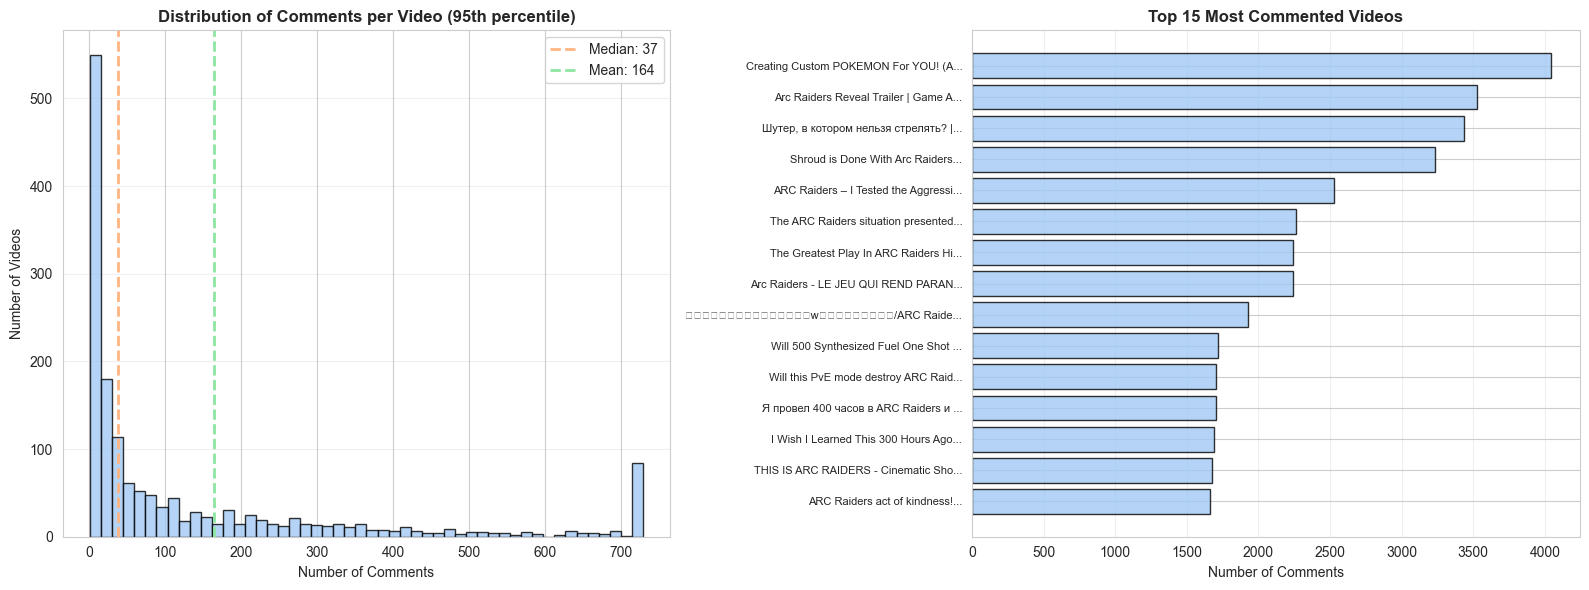

In [36]:
# Plotting them
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = sns.color_palette()
main_color = palette[0]
secondary_color = palette[1]
third_color = palette[2]

# 1. Distribution of comments per video
axes[0].hist(
    comments_per_video.clip(upper=comments_per_video.quantile(0.95)), 
    bins=50,
    edgecolor='black',
    alpha=0.8,
    color=main_color
)

axes[0].axvline(
    comments_per_video.median(),
    color=secondary_color,
    linestyle='--',
    linewidth=2,
    label=f'Median: {comments_per_video.median():.0f}'
)

axes[0].axvline(
    comments_per_video.mean(),
    color=third_color,
    linestyle='--',
    linewidth=2,
    label=f'Mean: {comments_per_video.mean():.0f}'
)

axes[0].set_title(
    'Distribution of Comments per Video (95th percentile)', 
    fontsize=12,
    fontweight='bold'
)
axes[0].set_xlabel('Number of Comments')
axes[0].set_ylabel('Number of Videos')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')


# 2. Top 15 videos
top_15_counts = [count for _, count in top_videos.head(15).items()]
top_15_labels = [f"{title[:35]}..." for _, title in 
                 [k for k, v in top_videos.head(15).items()]]

axes[1].barh(
    range(len(top_15_counts)),
    top_15_counts,
    color=main_color,
    alpha=0.8,
    edgecolor='black'
)

axes[1].set_yticks(range(len(top_15_counts)))
axes[1].set_yticklabels(top_15_labels, fontsize=8)
axes[1].set_xlabel('Number of Comments')
axes[1].set_title(
    'Top 15 Most Commented Videos',
    fontsize=12,
    fontweight='bold'
)
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_video_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()


### 6. Next Steps

Before performing the modelling and classification for trend analysis, we should perfom the necessary data wrangling and feature engineering. Some processes were highlighted here in the notebook earlier: handling multiple languages, considering the particular video popularity, and engineering for gaming-specific vocabulary. 

In [ ]:
# Saving the DataFrame for future use
DATA_DIR = os.path.join("..", "data")
os.makedirs(DATA_DIR, exist_ok=True)

df.to_csv(os.path.join(DATA_DIR, 'comments_data.csv'), index=True)